<p style="color:white; background:#07D; padding:12px; font-size:20px; font-style:italic; text-align:center">
<span style="width:49%; display:inline-block; text-align:left">Christophe Schlick</span>
<span style="width:49%; display:inline-block; text-align:right">schlick[at]u-bordeaux.fr</span>
<span style="font-size:48px; font-style:normal"><b>EXERCICES : PANDAS</b></span><br>
<span style="width:49%; display:inline-block; text-align:left">Version 2022-11</span>
<span style="width:49%; display:inline-block; text-align:right">Licence CC-BY-NC-ND</span></p>

L'objectif de cette feuille d'exercices est de voir comment mettre en oeuvre quelques unes des fonctionnalités fournies par le package **pandas**, basées sur l'utilisation des conteneurs **`series`** et **`dataframe`**.
En parallèle, pour l'affichage des données, on mettra en oeuvre la bibliothèque **seaborn**, une sur-couche de **matplotlib** spécialisée pour les figures liées à l'analyse statistiques des données. Avant de commencer cette feuille d'exercices, il est donc fortement recommandé de relire le notebook **07-Pandas.ipynb** qui contient les éléments de cours correspondants.

In [1]:
import numpy as np
import matplotlib.pyplot as mp
import pandas as pd # import du package 'pandas' avec alias 'pd'
import seaborn as sb # import du package 'seaborn' avec alias 'sb'
sb.set_style('ticks') # on choisit le style des figures (autres styles = white, dark, whitegrid, darkgrid)

<h2 style="padding:16px; color:white; background:#07D">Exercice F1 - Pokemon</h2>

On fournit un fichier CSV [**pokemon.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/pokemon.csv) contenant des informations diverses sur les 151 Pokemon de première génération.

En ouvrant le fichier directement avec l'environnement Jupyter, on peut constater que la première ligne du fichier contient les noms des colonnes de la table, et que la première colonne, nommée **`#`**, contient un indice numérique correspondant au numéro "officiel" du Pokemon selon le [**Pokedex**](https://www.pokepedia.fr/Liste_des_Pok%C3%A9mon_dans_l%27ordre_du_Pok%C3%A9dex_National#Liste_des_Pok%C3%A9mon). Ecrire les instructions permettant de récupérer le contenu du fichier sous la forme d'une table **pandas** en utilisant la colonne **`#`** pour l'index des lignes, et les labels fournis pour l'index des colonnes :

In [2]:
pkm = 'TODO'

In [3]:
pkm = pd.read_csv('CSV/pokemon.csv') # lecture du fichier (par défaut, la première ligne sert d'index)
pkm.index = pkm['#']; pkm.index.name = None; del pkm['#'] # on transforme la colonne '#' en index
pkm

,Name,Type 1,Type 2,Total,HP,Atk,Def,Spec Atk,Spec Def,Speed,Stage,Legendary
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,3,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
147,Dratini,Dragon,NaN,300,41,64,45,50,50,50,1,False
148,Dragonair,Dragon,NaN,420,61,84,65,70,70,70,2,False
149,Dragonite,Dragon,Flying,600,91,134,95,100,100,80,3,False
150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True


---
Les labels de certaines colonnes comportent des espaces, ce qui interdit de les utiliser avec un accès par attribut (notation pointée). Ecrire les instructions permettant de supprimer ces espaces :

In [4]:
# TODO

In [5]:
pkm.columns = [name.replace(' ','') for name in pkm.columns] # suppression de tous les espaces
pkm.iloc[[0,1,-2,-1],:] # affichage des 2 premières et des 2 dernières lignes

,Name,Type1,Type2,Total,HP,Atk,Def,SpecAtk,SpecDef,Speed,Stage,Legendary
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,2,False
150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True
151,Mew,Psychic,NaN,600,100,100,100,100,100,100,1,False


---
Vérifier les types de données pour les 12 colonnes :

In [6]:
# TODO

In [7]:
pkm.dtypes # type de données par colonne

Name         object
Type1        object
Type2        object
Total         int64
HP            int64
Atk           int64
Def           int64
SpecAtk       int64
SpecDef       int64
Speed         int64
Stage         int64
Legendary      bool
dtype: object

Afficher les statistiques descriptives pour les colonnes numériques de la table :

In [8]:
# TODO

In [9]:
pkm.describe() # statistiques descriptives par colonne

,Total,HP,Atk,Def,SpecAtk,SpecDef,Speed,Stage
count,151.00000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000,151.000000
mean,407.07947,64.211921,72.549669,68.225166,67.139073,66.019868,68.933775,1.582781
std,99.74384,28.590117,26.596162,26.916704,28.534199,24.197926,26.746880,0.676832
min,195.00000,10.000000,5.000000,5.000000,15.000000,20.000000,15.000000,1.000000
25%,320.00000,45.000000,51.000000,50.000000,45.000000,49.000000,46.500000,1.000000
50%,405.00000,60.000000,70.000000,65.000000,65.000000,65.000000,70.000000,1.000000
75%,490.00000,80.000000,90.000000,84.000000,87.500000,80.000000,90.000000,2.000000
max,680.00000,250.000000,134.000000,180.000000,154.000000,125.000000,140.000000,3.000000


Afficher le nombre de valeurs distinctes pour chaque colonne :

In [10]:
# TODO

In [11]:
pkm.nunique() # nombre de valeurs distinctes par colonne

Name         150
Type1         15
Type2         11
Total         74
HP            42
Atk           46
Def           44
SpecAtk       34
SpecDef       29
Speed         42
Stage          3
Legendary      2
dtype: int64

---
On constate qu'il y a 15 noms différents pour **Type1** et 11 pour **Type2**. Ecrire les instructions permettant de les afficher, classés par ordre alphabétique : 

In [12]:
# TODO

In [13]:
# création d'une fonction lambda pour extraire les données uniques d'une colonne et les combiner en 'str'
combine = lambda index: f"{index} : {' '.join(sorted(pkm[index].dropna().unique()))}"

print(combine('Type1')) # utilisation de la fonction 'combine' sur la colonne 'Type1'
print(combine('Type2')) # idem pour la colonne 'Type2'

Type1 : Bug Dragon Electric Fairy Fighting Fire Ghost Grass Ground Ice Normal Poison Psychic Rock Water
Type2 : Fairy Fighting Flying Grass Ground Ice Poison Psychic Rock Steel Water


On constate également qu'il y a 150 noms différents alors qu'il y a 151 lignes. Trouver le nom en doublon :

In [14]:
# TODO

In [15]:
print(pkm.Name[pkm.Name.duplicated()],'\n') # on trouve 'Nidoran'
pkm[pkm.Name == 'Nidoran'] # on affiche les 2 lignes concernées

32    Nidoran
Name: Name, dtype: object 



,Name,Type1,Type2,Total,HP,Atk,Def,SpecAtk,SpecDef,Speed,Stage,Legendary
29,Nidoran,Poison,NaN,275,55,47,52,40,40,41,1,False
32,Nidoran,Poison,NaN,273,46,57,40,40,40,50,1,False


Trouver sur le web la raison de ce doublon, et en déduire un moyen de le corriger dans la table :

In [16]:
# TODO

In [17]:
# 'Nidoran' est le seul Pokemon sexué de la génération 1 (cf. liens ci-dessous)
# https://www.pokebip.com/pokedex/pokemon/nidoran-m  ou  https://www.pokepedia.fr/Nidoran%E2%99%82
# https://www.pokebip.com/pokedex/pokemon/nidoran-f  ou  https://www.pokepedia.fr/Nidoran%E2%99%80

# on va donc renommer la version femelle en 'NidoranF' et la version mâle en 'NidoranM'
pkm.loc[29,'Name'] = 'NidoranF' # version femelle
pkm.loc[32,'Name'] = 'NidoranM' # version mâle
pkm[28:34] # affichage des 2 'Nidoran' et de leurs évolutions (Stage = 1, 2 ou 3)

,Name,Type1,Type2,Total,HP,Atk,Def,SpecAtk,SpecDef,Speed,Stage,Legendary
29,NidoranF,Poison,NaN,275,55,47,52,40,40,41,1,False
30,Nidorina,Poison,NaN,365,70,62,67,55,55,56,2,False
31,Nidoqueen,Poison,Ground,505,90,92,87,75,85,76,3,False
32,NidoranM,Poison,NaN,273,46,57,40,40,40,50,1,False
33,Nidorino,Poison,NaN,365,61,72,57,55,55,65,2,False
34,Nidoking,Poison,Ground,505,81,102,77,85,75,85,3,False


---
La colonne **Total** semble être égale à la somme des colonnes de **HP** à **Speed**. Confirmer ou infirmer cette hypothèse :

In [18]:
# TODO

In [19]:
all(pkm.Total == pkm.loc[:,'HP':'Speed'].sum(axis=1)) # test sur l'égalité pour toutes les lignes

True

En utilisant la fonction **`histplot`** du package **seaborn**, afficher l'histogramme de la colonne **Total** ainsi que la courbe d'estimation de sa densité de probabilité (***kde*** = kernel density estimation) :

In [20]:
# TODO

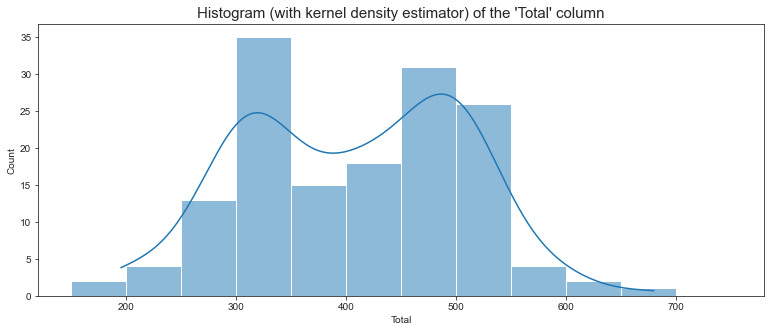

In [21]:
# la taille et le titre de l'image sont définis avec des commandes 'matplotlib'
mp.figure(figsize=(13,5)); sb.histplot(data=pkm.Total, bins=12, binrange=(150,750), kde=True)
mp.title("Histogram (with kernel density estimator) of the 'Total' column", fontsize=15);

Le résultat obtenu par l'estimateur de la densité de probabilités, montre clairement une distribution bimodale, avec un premier mode autour de 320 et un second autour de 480.

---
En utilisant la méthode **`groupby`**, écrire les instructions permettant de calculer la valeur moyenne de la colonne **Total** pour chacune des 12 catégories définies par **Type1** (afficher le résultat par ordre décroissant des moyennes obtenues). Même question pour les 11 catégories définies par **Type2** et pour les 3 catégories définies par **Stage** :

In [22]:
# TODO

In [23]:
#pkm[['Total','Type1']].groupby('Type1').mean().sort_values('Total', ascending=False)
#pkm[['Total','Type1']].groupby('Type1').describe() # idem avec les stats descriptives complètes
#pkm[['Total','Type2']].groupby('Type2').describe() # idem avec regroupement par 'Type2'
pkm[['Total','Stage']].groupby('Stage').describe() # idem avec regroupement par 'Stage'

Total                                                            
      count        mean         std    min    25%    50%     75%    max
Stage                                                                  
1      79.0  360.734177  101.885268  195.0  300.0  325.0  422.50  680.0
2      56.0  446.660714   68.663415  205.0  405.0  452.5  495.00  555.0
3      16.0  497.375000   48.622183  395.0  490.0  502.5  513.75  600.0

En utilisant les fonctions **`violinplot`** et **`swarmplot`** de **seaborn**, afficher les variations de la colonne **Total** pour chacun des 151 Pokemon en fonction de son **Type1**, de son **Type2**, et enfin de son **Stage** :

In [24]:
# TODO

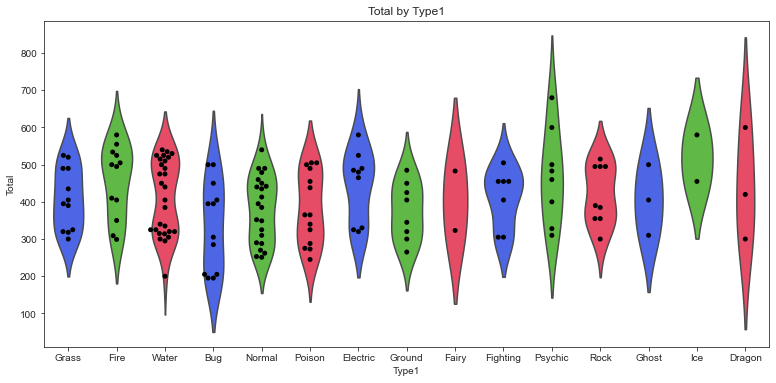

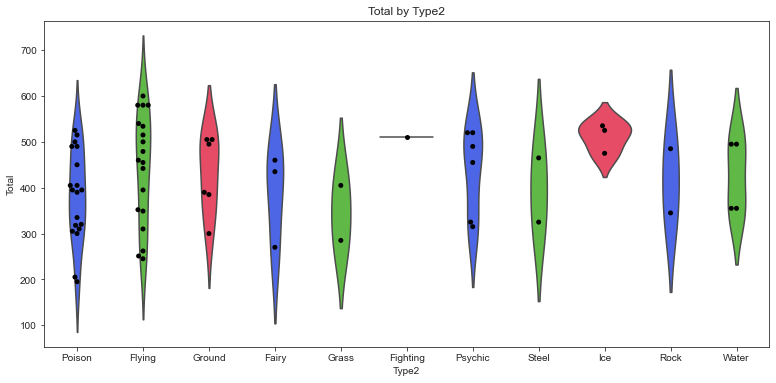

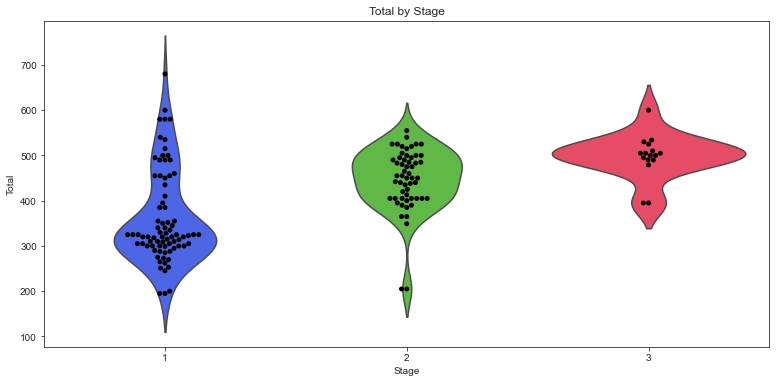

In [25]:
cmap = ['#35F','#5C3','#F35'] # création d'une colormap personnalisée

mp.figure(figsize=(13,6)); mp.title('Total by Type1')
sb.violinplot(x='Type1', y='Total', data=pkm, inner=None, palette=cmap)
sb.swarmplot(x='Type1', y='Total', data=pkm, color='k')
# les 2 modes identifiés précédemment apparaissent clairement sur les catégories groupes les plus peuplés

mp.figure(figsize=(13,6)); mp.title('Total by Type2')
sb.violinplot(x='Type2', y='Total', data=pkm, inner=None, palette=cmap)
sb.swarmplot(x='Type2', y='Total', data=pkm, color='k')
# ici, il y a trop peu de données pour la plupart des catégories (hormis Poison et Flying)

mp.figure(figsize=(13,6)); mp.title('Total by Stage')
sb.violinplot(x='Stage', y='Total', data=pkm, inner=None, palette=cmap)
sb.swarmplot(x='Stage', y='Total', data=pkm, color='k');
# les 3 distributions sont de natures très différentes

Cette dernière figure permet de comprendre la raison de la distribution bimodale observée à la question précédente : les Pokemon de **Stage 1** ont une forte densité autour de la valeur $300$, ceux de **Stage 3**, une forte densité autour de la valeur $500$, et les éléments de **State 2** une distribution relativement uniforme sur l'intervalle $[350,550]$.

---
On s'intéresse maintenant aux 4 caractéristiques **Atk**, **Def**, **SpecAtk** et **SpecDef**. Visualiser les variations de ces 4 colonnes à l'aide de la fonction **`boxplot`**, en y rajoutant l'affichage de la distribution sous-jacente avec la fonction **`swarmplot`** :

In [26]:
# TODO

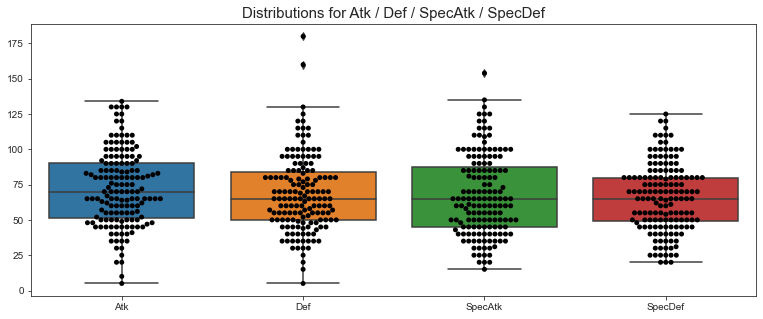

In [27]:
mp.figure(figsize=(13,5)); mp.title('Distributions for Atk / Def / SpecAtk / SpecDef', fontsize=15)
sb.boxplot(data=pkm.T['Atk':'SpecDef'].T) # affichage de type 'boites à moustaches'
sb.swarmplot(data=pkm.T['Atk':'SpecDef'].T, color='k'); # ajout de la distribution sous-jacente

On cherche à établir s'il existe des corrélations entre ces quatre paramètres. L'outil idéal pour avoir une vision d'ensemble est la fonction **`pairplot`**. Pour un complément d'information, on va mettre des couleurs différentes les trois valeurs de la colonne **Stage** (utilisation du paramètre optionnel **`hue='Stage'`**):

In [28]:
# TODO

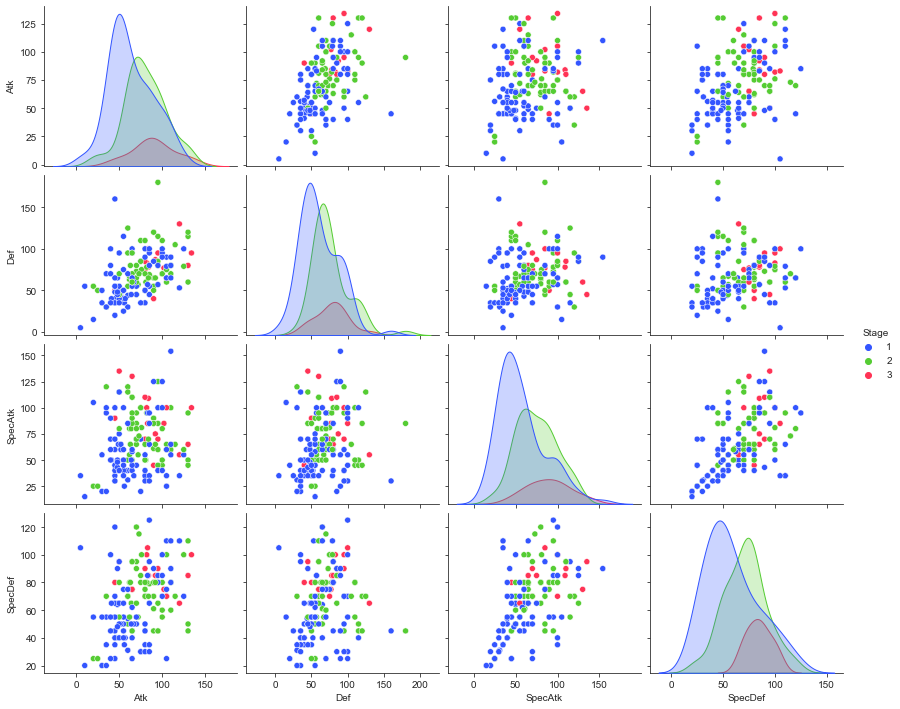

In [29]:
sb.pairplot(pkm, vars=['Atk','Def','SpecAtk','SpecDef'], hue='Stage', palette=cmap, aspect=1.2);

Les diagrammes ne sont pas très probants, le seul endroit où une correlation semble apparaître concerne les variables **SpecAtk** et **SpecDef** (et encore, c'est uniquement pour la première moitié de l'échelle des valeurs). On va utiliser la fonction **`regplot`** pour visualiser les relations entre ces deux variables, et tenter d'y appliquer une régression linéaire :

In [30]:
# TODO

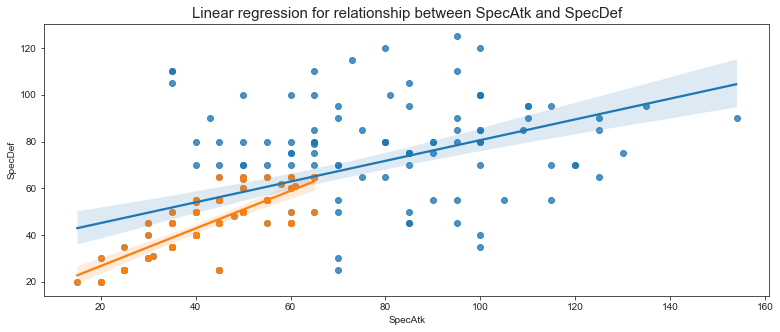

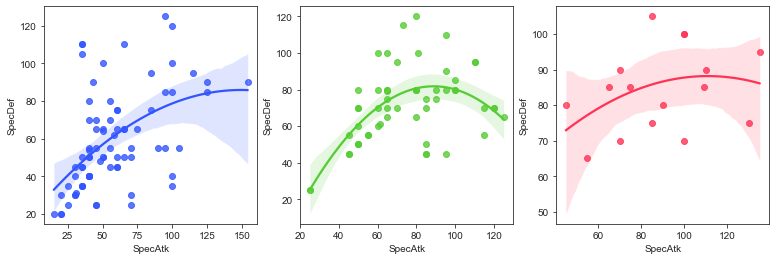

In [31]:
mp.figure(figsize=(13,5)); sb.regplot(data=pkm, x='SpecAtk', y='SpecDef', order=1)
sb.regplot(data=pkm[(pkm.SpecAtk < 70) & (pkm.SpecDef < 70)], x='SpecAtk', y='SpecDef', order=1)
mp.title('Linear regression for relationship between SpecAtk and SpecDef', fontsize=15);
# on met en sur-impression, la régression obtenue en se limitant aux valeurs faibles

mp.figure(figsize=(13,4)); 
mp.subplot(1,3,1); sb.regplot(data=pkm[pkm.Stage == 1], x='SpecAtk', y='SpecDef', order=2, color=cmap[0])
mp.subplot(1,3,2); sb.regplot(data=pkm[pkm.Stage == 2], x='SpecAtk', y='SpecDef', order=2, color=cmap[1])
mp.subplot(1,3,3); sb.regplot(data=pkm[pkm.Stage == 3], x='SpecAtk', y='SpecDef', order=2, color=cmap[2]);
# on effectue 3 régressions d'ordre 2 (polynôme quadratique) selon la valeur de la colonne 'Stage'

<h2 style="padding:16px; color:white; background:#07D">Exercice F2 - Fortune 500</h2>

On fournit un fichier CSV [**fortune500.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/fortune500.csv) qui contient 51 classements annuels (entre 1955 et 2005) établis par le magazine [**Fortune**](https://fortune.com/fortune500) et contenant les noms des 500 plus grandes entreprises américaines (au sens du chiffre d'affaires annuel).

Comme dans l'exercice prédédent, on peut constater que la première ligne du fichier contient les noms des colonnes de la table. Ecrire les instructions permettant de récupérer le contenu du fichier sous la forme d'une table **pandas** en gardant l'index par défaut pour les lignes et en utilisant les labels fournis pour l'index des colonnes. Ensuite supprimer la colonne **`Profit (in millions)`** dont on ne se servira pas, et renommer la colonne **`Revenue (in millions)`** en **`Revenue`** :

In [32]:
top500 = 'TODO'

In [33]:
top500 = pd.read_csv('CSV/fortune500.csv') # lecture du fichier CSV
del top500['Profit (in millions)'] # suppression de la colonne 'Profit...'
top500.rename(columns={'Revenue (in millions)':'Revenue'}, inplace=True) # changement de nom pour 'Revenue'
top500

,Year,Rank,Company,Revenue
0,1955,1,General Motors,9823.5
1,1955,2,Exxon Mobil,5661.4
2,1955,3,U.S. Steel,3250.4
3,1955,4,General Electric,2959.1
4,1955,5,Esmark,2510.8
...,...,...,...,...
25495,2005,496,Wm. Wrigley Jr.,3648.6
25496,2005,497,Peabody Energy,3631.6
25497,2005,498,Wendy's International,3630.4
25498,2005,499,Kindred Healthcare,3616.6


---
On veut connaitre le nom de toutes les sociétés qui ont été classsées **Top 1** au moins une fois sur les 51 classements annuels, et les afficher par ordre décroissant du nombre de classements dans cette position : 

In [34]:
top1 = 'TODO'

In [35]:
top1 = top500[top500.Rank == 1] # extraction des lignes correspondant aux 'Top 1' annuels
count = top1.Company.value_counts() # nombre d'occurrences pour chaque 'Company'
pd.DataFrame({'Company':count.index, 'Years as Top1':count.values}) # on affiche sous forme de table

,Company,Years as Top1
0,General Motors,37
1,Exxon Mobil,10
2,Wal-Mart Stores,4


In [36]:
top10 = 'TODO'

Même question avec un classement dans le **Top 10**, en se limitant aux sociétés qui y ont été classées au moins 20 fois :

In [37]:
top10 = top500[top500.Rank <= 10] # extraction des lignes correspondant aux 'Top 1' annuels
count = top10.Company.value_counts() # nombre d'occurrences pour chaque 'Company'
count = count[count >= 20] # suppression des lignes avec un nombre d'occurrences < 20
pd.DataFrame({'Company':count.index, 'Years in Top10':count.values}) # on affiche sous forme de table

,Company,Years in Top10
0,General Motors,51
1,Exxon Mobil,51
2,Ford Motor,50
3,General Electric,49
4,Mobil,43
5,Intl. Business Machines,41
6,Texaco,36
7,Chrysler,28
8,Gulf Oil,25


---
Afficher sur un même graphique avec la fonction **`lineplot`**, l'évolution du chiffre d'affaires moyen du top 1, du top 10 et de l'ensemble du top 500 entre les années 1955 et 2005 :

In [38]:
revenues = 'TODO'

In [39]:
mean_revenue = lambda data: data.groupby('Year').Revenue.mean().reset_index() # calcul de la moyenne annuelle
revenues = [mean_revenue(group) for group in (top1,top10,top500)] # moyenne annuelle pour les 3 regroupements
groups = 'Top 1:Top 10:Top 500'.split(':') # noms utilisés dans la légende pour les 3 regroupements
for group, revenue in zip(groups,revenues): revenue['Group'] = group # rajout d'une colonne 'Group'
revenues = pd.concat(revenues).reset_index(drop=True) # concaténation des 3 regroupements dans une même table
revenues.iloc[[0,1,-2,-1],:].round() # affichage des 2 premières et des 2 dernières lignes

,Year,Revenue,Group
0,1955,9824.0,Top 1
1,1956,12443.0,Top 1
151,2004,14931.0,Top 500
152,2005,16496.0,Top 500


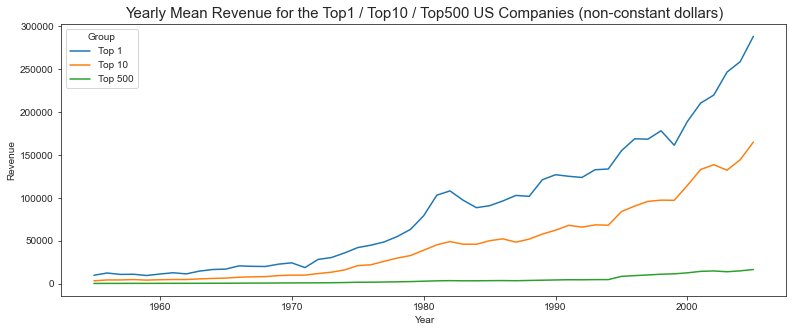

In [40]:
mp.figure(figsize=(13,5)); sb.lineplot(x='Year', y='Revenue', hue='Group', data=revenues)
mp.title("Yearly Mean Revenue for the Top1 / Top10 / Top500 US Companies (non-constant dollars)", fontsize=15);

Le défaut majeur de ce graphique est qu'il n'inclut pas l'effet de l'inflation (**1\$** de 1955 n'a évidemment rien à voir avec **1\$** de 2005). Pour corriger cette erreur, il faut inclure l'évolution annuelle de l'indice des prix à la consommation aux Etats-Unis (***Historical Consumer Price Index***) qui se trouve (par exemple) sur [**cette page**](https://inflationdata.com/Inflation/Consumer_Price_Index/HistoricalCPI.aspx). Il faut donc récupérer cette table (via la fonction **`pd.read_html`**), ne garder que la colonne de décembre et les lignes entre 1955 et 2005, et s'en servir pour regénérer le graphique précédent en dollars constants :

In [41]:
cpi = 'TODO'

In [42]:
# la fonction 'read_html' va identifier toutes les balise <TABLE> dans le fichier HTML
# et renvoie une liste de tables au format 'pandas' (dans la page lue, il n'y en qu'une à l'indice 0)
cpi = pd.read_html('https://inflationdata.com/Inflation/Consumer_Price_Index/HistoricalCPI.aspx')[0]
cpi.iloc[[0,1,-2,-1],:] # affichage des 2 premières et des 2 dernières lignes

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Ave.
0,2022,281.148,283.716,287.504,289.109,292.296,296.311,296.276,296.171,296.808,298.012,NaN,NaN,NaN
1,2021,261.582,263.014,264.877,267.054,269.195,271.696,273.003,273.567,274.310,276.589,277.948,278.802,270.97
108,1914,10.000,9.900,9.900,9.800,9.900,9.900,10.000,10.200,10.200,10.100,10.200,10.100,10.00
109,1913,9.800,9.800,9.800,9.800,9.700,9.800,9.900,9.900,10.000,10.000,10.100,10.000,9.90


In [43]:
# on ne conserve que les lignes entre 1955 et 2005, et que les colonnes 'Year' et 'Dec'
cpi = cpi[(cpi.Year > 1954) & (cpi.Year < 2006)][['Year','Dec']].reset_index(drop=True) # extraction données
cpi.iloc[[0,1,-2,-1],:] # affichage des 2 premières et des 2 dernières lignes

,Year,Dec
0,2005,196.8
1,2004,190.3
49,1956,27.6
50,1955,26.8


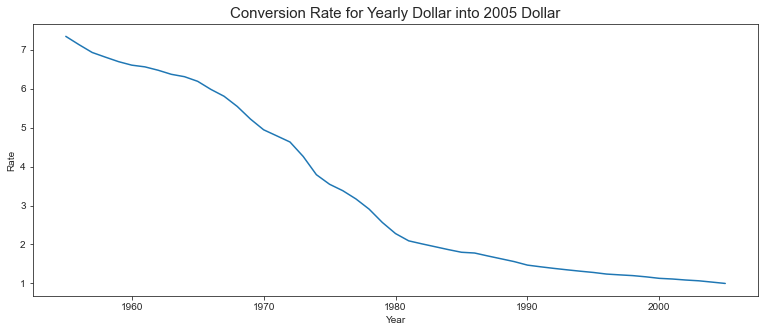

In [44]:
cpi['Rate'] = cpi['Dec'][0] / cpi['Dec'] # calcul du taux de conversion par rapport à un dollar de 2005
mp.figure(figsize=(13,5)); mp.title('Conversion Rate for Yearly Dollar into 2005 Dollar', fontsize=15)
sb.lineplot(x='Year', y='Rate', data=cpi); # on affiche l'évolution du taux

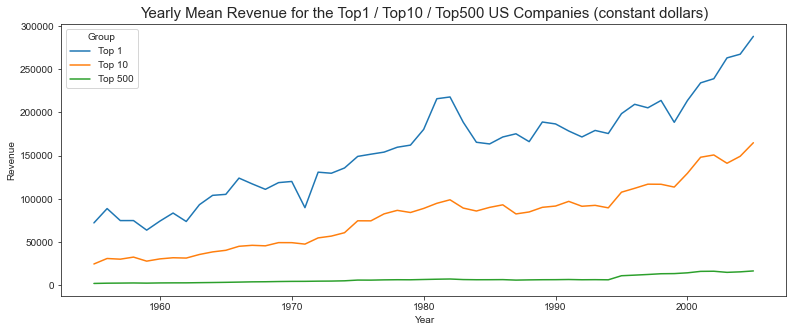

In [45]:
values = revenues.Revenue.values; rates = cpi.Rate.values[::-1] # récupération des vecteurs 'numpy'
revenues.Revenue = values * np.tile(rates, 3) # mise à jour des chiffres d'affaires en dollars constants
mp.figure(figsize=(13,5)); sb.lineplot(x='Year', y='Revenue', hue='Group', data=revenues)
mp.title("Yearly Mean Revenue for the Top1 / Top10 / Top500 US Companies (constant dollars)", fontsize=15);

---
Et pour finir, on cherche à afficher l'histogramme empilé des chiffres d'affaires (transformés en dollars constants) des sociétés du **Top 10**, pour l'ensemble des 51 classements. Pour cela il faut d'abord
créer une colonne pour chacun des 10 rangs, à l'aide de la fonction **`pivot_table`** puis utiliser la méthode **`plot`** avec les paramètres **`kind='bar'`** et **`stacked=True`** :

In [46]:
import warnings; warnings.filterwarnings('ignore') # suppression des 'warning' pour 'setting with copy'
# TODO

In [47]:
import warnings; warnings.filterwarnings('ignore') # suppression des 'warning' pour 'setting with copy'
top10.Revenue = top10.Revenue.values * np.repeat(rates, 10) # mise à jour des valeurs en dollars constants
top10.iloc[[0,1,-2,-1],:].round(0) # affichage des 2 premières et des 2 dernières lignes

,Year,Rank,Company,Revenue
0,1955,1,General Motors,72137.0
1,1955,2,Exxon Mobil,41573.0
25008,2005,9,American Intl. Group,98610.0
25009,2005,10,Intl. Business Machines,96293.0


In [48]:
data = pd.pivot_table(top10, index='Year', columns='Rank', values='Revenue') # création d'une table pivot
data.iloc[[0,1,-2,-1],:].round(0) # affichage des 2 premières et des 2 dernières lignes

Rank,1,2,3,4,5,6,7,8,9,10
Year,,,,,,,,,,
1955,72137.0,41573.0,23869.0,21730.0,18438.0,15212.0,15099.0,12523.0,12510.0,12393.0
1956,88726.0,44725.0,39888.0,29218.0,24716.0,22072.0,17142.0,14950.0,14031.0,13613.0
2004,267517.0,220481.0,202328.0,170115.0,138770.0,116795.0,102865.0,97948.0,92175.0,84077.0
2005,288189.0,270772.0,193517.0,172233.0,152363.0,147967.0,121663.0,108276.0,98610.0,96293.0


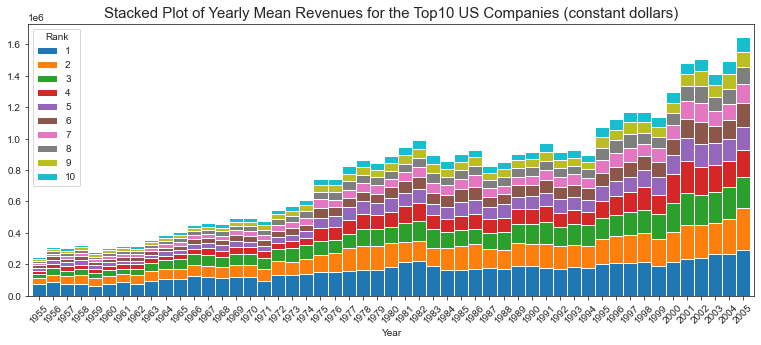

In [49]:
data.plot(kind='bar', stacked=True, figsize=(13,5), width=1.0); mp.xticks(rotation=45) # histogramme empilé
mp.title("Stacked Plot of Yearly Mean Revenues for the Top10 US Companies (constant dollars)", fontsize=15);

<h2 style="padding:16px; color:white; background:#07D">Exercice F3 - Population des USA</h2>

On cherche à établir quelques statistiques sur (une partie de) la base de données du recensement aux Etats-Unis. On fournit trois fichiers :

* L'évolution de la population, Etat par Etat, entre 1990 et 2013 : [**usa-pops.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/usa-pops.csv)
* La superficie de chaque Etat (en squared miles) : [**usa-areas.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/usa-areas.csv)
* L'abréviation et le nom officiel de chacun des 50 Etats : [**usa-names.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/usa-names.csv)

A partir de ces fichiers, et sans avoir plus d'explications sur la manière de procéder, écrire la liste des instructions à exécuter pour obtenir les résultats suivants :

* Convertir l'ensemble des surfaces des 50 Etats (uniquement les 50 Etats fédéraux) en **km$^2$** et afficher les statistiques descriptives associées
* Vérifier si, pour chaque année, la population totale des USA est bien égale à la somme de celle des 50 Etats, ou si les totaux fournis par le fichier incluent la population des 2 territoires non-fédéraux :<br> **DC** = *District of Columbia* et **PR** = *Puerto Rico*
* Tracer l'évolution de la population globale des Etats-Unis entre 1990 et 2013, selon trois courbes différentes : les personnes mineures, les personnes majeures, la somme des deux
* Calculer l'évolution de la densité de population (habitants par km$^2$) pour chaque Etat, puis tracer (sur une même figure) l'évolution des 3 Etats les plus denses et des 3 Etats les moins denses
* Calculer pour chaque année, l'évolution relative de la population de chaque Etat, puis tracer sous forme
de nuage de points, la relation entre la population totale de chaque Etat et son évolution relative

> **Note :** La table des superficies utilise les noms complets des Etats, alors que la table des populations utilise le sigle sur 2 caractères. Pour utiliser correctement les deux tables, il faudra donc se servir de la troisième table qui associe les noms et les sigles pour les 50 Etats fédéraux.

In [50]:
names = pd.read_csv('CSV/usa-names.csv'); names.iloc[[0,1,-2,-1],:]

,name,state
0,Alabama,AL
1,Alaska,AK
48,Wisconsin,WI
49,Wyoming,WY


In [51]:
areas = pd.read_csv('CSV/usa-areas.csv'); areas.iloc[[0,1,-2,-1],:]

,state,area (sq. mi)
0,Alabama,52423
1,Alaska,656425
50,District of Columbia,68
51,Puerto Rico,3515


In [52]:
pops = pd.read_csv('CSV/usa-pops.csv'); pops.iloc[[0,1,-2,-1],:]

,state,age,year,population
0,AL,minor,2012,1117489.0
1,AL,total,2012,4817528.0
2542,USA,minor,2012,73708179.0
2543,USA,total,2012,313873685.0


---

In [53]:
# conversion des superficies en kilomètres carrés (1 mi^2 = 2.59 km^2) et affichage des stats descriptives
areas['area'] = areas['area (sq. mi)']*2.59 # conversion en kilomètres carrés
areas.state = names.state # remplacement des noms des Etats par les sigles
del areas['area (sq. mi)'] # suppression de l'ancienne colonne des superficies
areas.dropna(inplace=True) # suppression des 2 dernières lignes qui ne sont pas des Etats fédéraux
areas.describe().astype(int) # statistiques descriptives + conversion des valeurs en entiers

,area
count,50
mean,196157
std,249247
min,4001
25%,96911
50%,147881
75%,219040
max,1700140


---

In [54]:
# pour savoir comment est calculée la population globale des USA, on fait le test sur l'année 2013
pop2013 = pops[(pops.year == 2013) & (pops.age == 'total')]
pop2013.iloc[[0,1,2,-3,-2,-1],:] # affichage des 3 premières et 3 dernières lignes

,state,age,year,population
9,AL,total,2013,4833722.0
87,AK,total,2013,735132.0
103,AZ,total,2013,6626624.0
2408,WY,total,2013,582658.0
2487,PR,total,2013,3615086.0
2535,USA,total,2013,316128839.0


In [55]:
print('USA global =', pop2013[-1:].sum().population)
print('Sum of 50 States =', pop2013[pop2013.state.isin(names.state)].sum().population)
print('Sum of 50 States + DC =', pop2013[:-2].sum().population)
print('Sum of 50 States + DC + PR =', pop2013[:-1].sum().population)
# La population globale des USA est donc calculée comme celle des 50 Etats + celle de Washington DC)

USA global = 316128839.0
Sum of 50 States = 315482390.0
Sum of 50 States + DC = 316128839.0
Sum of 50 States + DC + PR = 319743925.0


---

In [56]:
# extraction de la population globale et rajout d'une colonne 'major' pour la population majeure
usa = pops[pops.state == 'USA'] # population globale (tous Etats confondus)
usa = pd.pivot_table(usa, index='year', columns='age', values='population') # transformation en table pivot
usa['major'] = usa.total - usa.minor # création d'une colonne pour la population majeure
usa.iloc[[0,1,-2,-1],:] # affichage des 2 premières et 2 dernières lignes

age,minor,total,major
year,,,
1990,64218512.0,249622814.0,185404302.0
1991,65313018.0,252980942.0,187667924.0
2012,73708179.0,313873685.0,240165506.0
2013,73585872.0,316128839.0,242542967.0


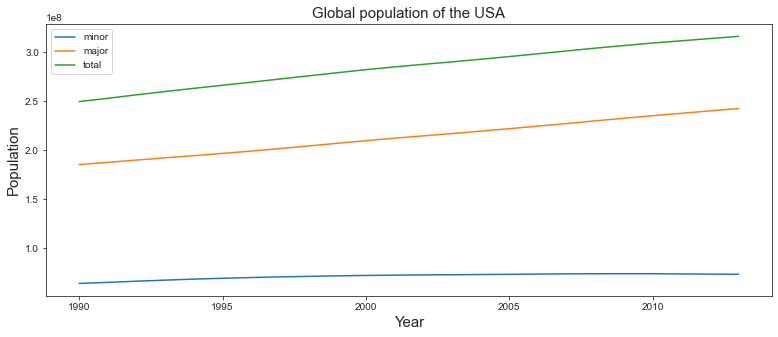

In [57]:
# affichage de l'évolution de la population globale entre 1990 et 2013
mp.figure(figsize=(13,5)); mp.title("Global population of the USA", fontsize=15)
mp.xlabel('Year', fontsize=15); mp.ylabel('Population', fontsize=15)
for age in "minor major total".split(): sb.lineplot(data=usa[age], label=age)

---

In [58]:
# réorganisation de la table 'pops' (uniquement population totale des 50 Etats + tri par Etat et par année)
pops = pops[(pops.age == 'total') & pops.state.isin(names.state)] # extraction population totale des 50 Etats
pops = pops.sort_values(['state','year']).drop(columns='age') # tri par Etat/année + suppression colonne 'age'
pops.reset_index(drop=True, inplace=True) # regénération de l'index après le tri
pops.iloc[[0,1,-2,-1],:] # affichage des 2 premières et 2 dernières lignes

,state,year,population
0,AK,1990,553290.0
1,AK,1991,570193.0
1198,WY,2012,576626.0
1199,WY,2013,582658.0


In [59]:
# ajout d'une colonne 'density' dans la table 'pops' réorganisée
pops['density'] = pops.population / areas.area.values.repeat(24) # chaque Etat est répété sur 24 lignes
pops.iloc[[0,1,-2,-1],:] # affichage des 2 premières et 2 dernières lignes

,state,year,population,density
0,AK,1990,553290.0,4.075034
1,AK,1991,570193.0,4.199526
1198,WY,2012,576626.0,2.276018
1199,WY,2013,582658.0,2.299827


In [60]:
# recherche des noms des 3 Etats les plus denses et des 3 Etats les moins denses
lo = pops.groupby('state').density.min().sort_values() # tri croissant sur les densités min
hi = pops.groupby('state').density.max().sort_values(ascending=False) # tri décroissant sur les densités max
hilo = list(hi[:3].index) + list(lo[:3].index) # extraction des noms des 3 plus denses et des 3 moins denses
hilo

['VA', 'RI', 'CT', 'WY', 'MT', 'ND']

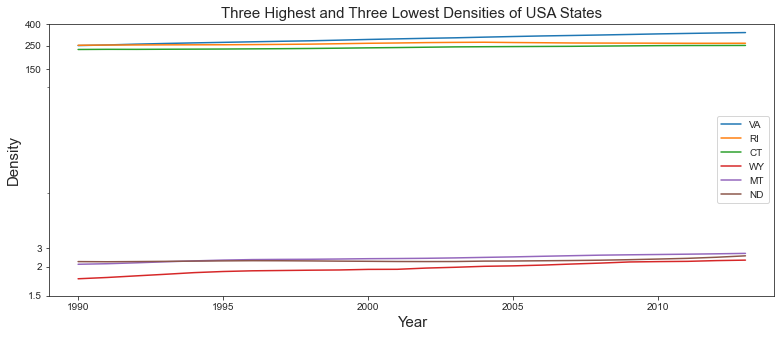

In [61]:
# affichage de l'évolution de la densité pour les 3 Etats les plus denses et les 3 Etats les moins denses
mp.figure(figsize=(13,5)); mp.title("Three Highest and Three Lowest Densities of USA States", fontsize=15)
mp.xlabel('Year', fontsize=15); mp.ylabel('Density', fontsize=15); mp.yscale('symlog')
mp.axis([1989,2014,1.5,400]); mp.yticks([1.5,2,3,150,250,400], labels=[1.5,2,3,150,250,400])
for state in hilo: # extraction et affichage de la densité pour chacun des 6 Etats sélectionnés
  sb.lineplot(x='year', y='density', data=pops[pops.state == state], label=state)

In [62]:
rate = pops.population.values.copy() # extraction de la population sous forme de matrice 'numpy'
rate[1:] = rate[1:]/rate[:-1] - 1 # calcul du taux d'accroissement par rapport à l'année N-1
pops['rate'] = rate # création d'une nouvelle colonne pour stocker le taux d'accroissement
pops.rate[pops.year == 1990] = np.nan # suppression des valeurs (fausses) pour l'année de départ
pops.iloc[[0,1,2,-3,-2,-1],:] # affichage des 3 premières et 3 dernières lignes

,state,year,population,density,rate
0,AK,1990,553290.0,4.075034,NaN
1,AK,1991,570193.0,4.199526,0.030550
2,AK,1992,588736.0,4.336097,0.032521
1197,WY,2011,567329.0,2.239321,0.005507
1198,WY,2012,576626.0,2.276018,0.016387
1199,WY,2013,582658.0,2.299827,0.010461


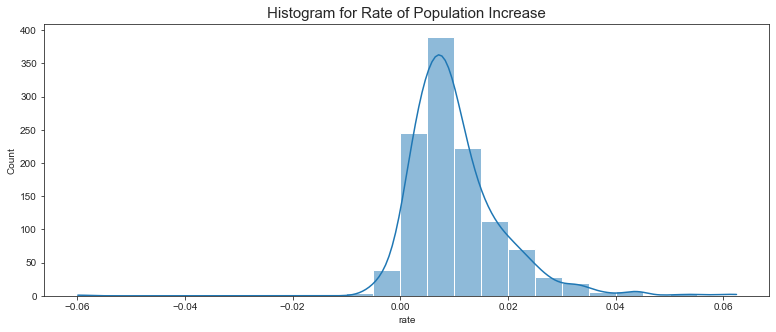

In [63]:
mp.figure(figsize=(13,5)); mp.title('Histogram for Rate of Population Increase', fontsize=15)
sb.histplot(data=pops.rate, bins=24, binrange=(-0.06,0.06), kde=True);
# on constate que la quasi-totalité des taux d'accroissement sont compris entre 0 et 0.03

In [64]:
# on cherche les cas extrêmes (décroissance forte ou croissance forte)
pops[(pops.rate < -0.02) | (pops.rate > 0.04)].sort_values('rate')
# un seul Etat en décroissance forte sur la période : Louisiane en 2006
# un seul Etat en croissance forte sur la période : Nevada pour la décennie 1991-2000

,state,year,population,density,rate
424,LA,2006,4302665.0,32.044068,-0.059861
770,NV,1992,1351367.0,9.694419,0.042583
782,NV,2004,2346222.0,16.831297,0.043299
778,NV,2000,2018741.0,14.482018,0.043429
777,NV,1999,1934718.0,13.879255,0.043992
77,AZ,1995,4432499.0,32.179865,0.044147
76,AZ,1994,4245089.0,30.819272,0.044189
771,NV,1993,1411215.0,10.123756,0.044287
776,NV,1998,1853192.0,13.294405,0.050500
774,NV,1996,1666320.0,11.953825,0.053581


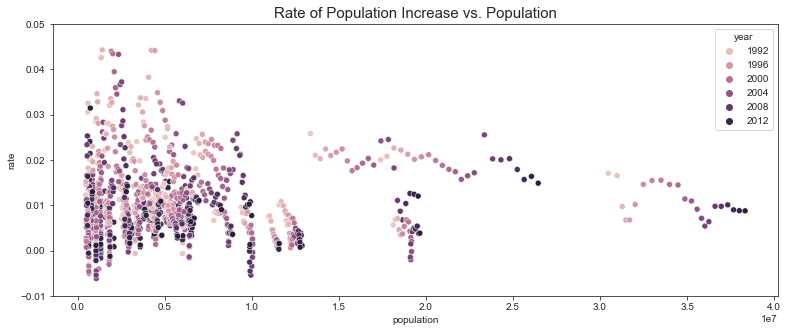

In [65]:
mp.figure(figsize=(13,5)); mp.title('Rate of Population Increase vs. Population', fontsize=15)
sb.scatterplot(data=pops, x='population', y='rate', hue='year'); mp.ylim(-0.01,0.05);

<h2 style="padding:16px; color:white; background:#07D">Exercice F3 - Equipements publics Bordeaux Metropole</h2>

La métropole de Bordeaux propose un grand nombre de [**jeux de données en OpenData**](https://opendata.bordeaux-metropole.fr) dont on a extrait les trois fichiers suivants (en supprimant quelques colonnes pour alléger la taille des données) :

* La liste (relativement) complète des adresses postales de la métropole : [**bx-adresses.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/bx-adresses.csv)
* La liste complète des équipements publics, classé en 15 catégories : [**bx-equi-pub.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/bx-equi-pub.csv)
* La liste des codes et des titres asssociés à ces 15 catégories : [**bx-code-equi.csv**](https://www.labri.fr/perso/schlick/outinfo/CSV/bx-code-equi.csv)

On cherche à exploiter ces fichiers pour obtenir une visualisation géolocalisée des équipements publics de la métropole. Il existe plusieurs bibliothèques pour Python permettant la création et la visualisation de cartes contenant des données géolocalisées, la plus simple d'accès est très certainement la bibliothèque [**folium**](https://python-visualization.github.io/folium) qui offre un "wrapper" simplifié pour la bibliothèque [**leaflet.js**](https://leafletjs.com) écrite en JavaScript. Malheureusement, la bibliothèque **folium** n'est pas installée par défaut avec la distribution **Anaconda**, il faut donc l'installer manuellement pour pouvoir l'utiliser. Cela est possible sur vos postes personnels (les instructions se trouvent dans les liens ci-dessous) mais pas sur les postes du CREMI, où il faudra impérativement passer sur l'environnement **binder** pour utiliser cette bibliothèque.

Pour la mise en oeuvre de **folium**, il est conseillé de commencer par lire les deux (courts) tutos suivants : un [**exemple d'introduction**](https://towardsdatascience.com/creating-a-simple-map-with-folium-and-python-4c083abfff94) tiré du site **towardsdatascience**, et le [**quickstart**](https://python-visualization.github.io/folium/quickstart.html) de la documentation officiel du package.

Ensuite, sans avoir d'explications complémentaires sur la manière de procéder, écrire la liste des instructions à exécuter pour obtenir les résultats suivants :

* Afficher l'histogramme du nombre d'équipements publics pour chacune des 15 catégories
* Créer et afficher une carte contenant l'ensemble des 5600 équipements publics de la métropole : on utilisera un marqueur graphique d'une couleur ou forme différente pour chaque catégorie, et chaque marqueur devra afficher un popup fournissant des informations complètes sur l'équipement sélectionné)
* Pour certains équipement, la donnée de la colonne **`adresse`** est manquante. En utilisant le fichier des adresses et les coordonnées GPS, trouver l'adresse la plus probable pour chacun de ces équipements.


In [66]:
adres = pd.read_csv('CSV/bx-adresses.csv')
adres.iloc[[0,1,-2,-1],:] # 214929 lignes

,gid,numero,voie,cp,commune,lon,lat
0,174605,6,Rue Emile Zola,33140,Villenave-d'Ornon,-0.585113,44.759917
1,2476,8,Place Ernest Renan,33140,Villenave-d'Ornon,-0.583350,44.762805
214927,71620,4,Rue Tiffonet,33800,Bordeaux,-0.572051,44.830036
214928,71618,3,Rue Tiffonet,33800,Bordeaux,-0.571971,44.829995


In [67]:
equis = pd.read_csv('CSV/bx-equi-pub.csv')
equis.iloc[[0,1,-2,-1],:] # 5600 lignes

,nom,code,type,gid,adresse,lon,lat
0,Prieuré de Cayac,D,D6,1262,NaN,-0.619363,44.765261
1,Maison de la nature,D,D5,5178,53 rue du Moulineau,-0.603450,44.770664
5598,Ecole Supérieure des Technologies Electronique...,A,A5,233,44 rue de la Faiencerie,-0.556906,44.861201
5599,Ecole Elémentaire Dupaty,A,A2,235,87 rue Dupaty,-0.561566,44.860395


In [68]:
codes = pd.read_csv('CSV/bx-code-equi.csv'); codes.index = codes.code; del codes['code']
codes.iloc[[0,1,-2,-1],:] # 15 ligness

,titre
code,
A,Enseignement divers et formation
B,Santé et action sociale
O,Commune
P,Petite enfance


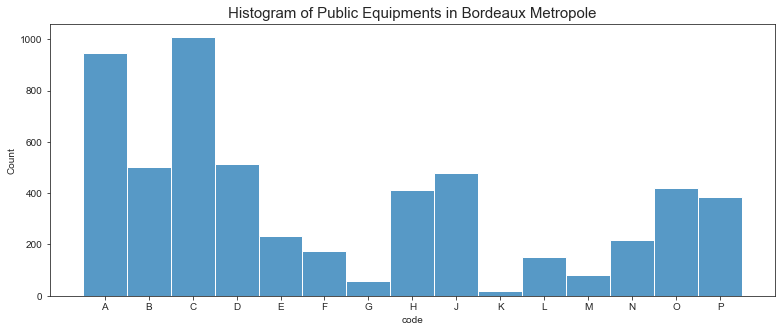

In [69]:
mp.figure(figsize=(13,5)); mp.title('Histogram of Public Equipments in Bordeaux Metropole', fontsize=15)
sb.histplot(equis.code, x=equis.code.sort_values());

In [70]:
import folium as fl
center = (equis.lat.mean(), equis.lon.mean()) # calcul du centre de gravité
bx = fl.Map(location=center, tiles='OpenStreetMap', zoom_start=12) # création de la carte
bx # affichage de la carte de base

In [71]:
colors = sb.color_palette('Spectral',15).as_hex() # extraction de 15 couleurs depuis la palette 'Spectral'
colors = dict(zip(codes.index, colors)) # création d'un dictionnaire associé codes d'équipement et couleurs
colors

{'A': '#c1274a',
 'B': '#dd4a4c',
 'C': '#f06744',
 'D': '#f98e52',
 'E': '#fdb567',
 'F': '#fed481',
 'G': '#feec9f',
 'H': '#ffffbe',
 'J': '#eff9a6',
 'K': '#d6ee9b',
 'L': '#b1dfa3',
 'M': '#86cfa5',
 'N': '#5eb9a9',
 'O': '#3d95b8',
 'P': '#4471b2'}

In [72]:
for code in 'EGKN': # géolocalisation d'un sous-ensemble des équipements (catégories: E, G, K et N)
  data = equis[equis.code == code]; titre = codes.loc[code].titre; color = colors[code]
  for n in range(len(data)): # on itère sur les lignes correspondant au code d'équipement
    nom, lon, lat = data.iloc[n,[0,-2,-1]] # nom et coordonnées GPS de l'équipement à localiser
    icon = fl.Icon(icon='stop', color='black', icon_color=color) # icon pour la balise de localisation
    popup = fl.Popup(f"<b>{nom}</b><br><i>({titre})</i>", min_width=200, max_width=300) # popup de la balise
    fl.Marker([lat, lon], popup=popup, icon=icon).add_to(bx) # ajout de la balise sur la carte
bx # affichage de la carte avec les balises de localisation des équipements

In [73]:
def nearest_address(n):
  """find nearest postal address for public equipment at row 'n' in database"""
  equi = equis.iloc[n]; coords = equi[-2:].values.astype(float) # coordonnées GPS de l'adresse recherchée
  # on calcule la distance euclidienne avec les coords GPS pour chaque ligne de la table 'adres'
  gps = adres[['lon','lat']].values - coords; gps *= gps; gps = gps.sum(axis=1)
  nearest = adres.iloc[gps.argmin(),:] # on récupère la ligne correspondant à la distance minimale
  print(f"Name = {equi.nom} (code = {equi.code}, type = {equi.type})")
  print(f"Initial coords = ({equi.lon},{equi.lat})")
  print(f"Nearest coords = ({nearest.lon},{nearest.lat})")
  print(f"Initial address = {equi.adresse}")
  print(f"Nearest address = {nearest.numero} {nearest.voie}, {nearest.cp} {nearest.commune}\n")

In [74]:
# on teste la fonction sur 20 équipements aléatoires
for n in np.random.randint(0, len(equis), size=20): nearest_address(n)

Name = Résidence Universitaire Budos (code = A, type = A7)
Initial coords = (-0.5865365,44.8260904)
Nearest coords = (-0.5862035,44.8263441)
Initial address = 17 rue de Budos
Nearest address = 17 Rue de Budos, 33000 Bordeaux

Name = BxMétro - Centre Voies Grands Trafic (code = M, type = M6)
Initial coords = (-0.5499494,44.8840977)
Nearest coords = (-0.5500703,44.8838904)
Initial address = nan
Nearest address = 201 Avenue de Labarde, 33300 Bordeaux

Name = Pôle Territorial de Solidarité des Graves (code = B, type = B10)
Initial coords = (-0.5891459,44.813521)
Nearest coords = (-0.589302,44.8136794)
Initial address = 226 cours Gambetta
Nearest address = 226 Cours Gambetta, 33400 Talence

Name = Collège Montessori Internationale de Bordeaux (code = A, type = A3)
Initial coords = (-0.6424829,44.773096)
Nearest coords = (-0.6423956,44.7732547)
Initial address = nan
Nearest address = 4 Rue de l'Europe, 33170 Gradignan

Name = Parking Barrière du Médoc - Schuman (code = J, type = J10)
Initial

---